# OptiVest Nifty-50 Exploratory Data Analysis

This notebook profiles the real PostgreSQL-loaded Nifty-50 dataset used by OptiVest. It examines coverage, sectors, prices, returns, correlations, volatility, and fundamentals without reading the source CSVs or modifying the database. The goal is to make the optimizer's evidence base visible before any model is fitted.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sqlalchemy import select, func, and_
from sqlalchemy.ext.asyncio import async_sessionmaker

REPO_ROOT = next(
    candidate for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "backend" / "app").is_dir()
)
BACKEND_ROOT = REPO_ROOT / "backend"
if str(BACKEND_ROOT) not in sys.path:
    sys.path.insert(0, str(BACKEND_ROOT))
os.chdir(BACKEND_ROOT)

from app.core.config import get_settings
from app.db.session import create_engine

SETTINGS = get_settings()
ENGINE = create_engine()
SessionLocal = async_sessionmaker(ENGINE, expire_on_commit=False, autoflush=False)

sns.set_theme(style="whitegrid", context="notebook")
OPTIVEST = {"navy": "#14213D", "teal": "#00A896", "gold": "#FCA311", "red": "#D1495B"}
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"Repository: {REPO_ROOT}")
print(f"Database configured by app.core.config: {SETTINGS.database_url.split('@')[-1]}")

Repository: P:\Placement\Projects\Github Projects\IT\OR-OptiVest
Database configured by app.core.config: localhost:5433/optivest


## Database coverage

Counts and coverage are queried through the application's configured asynchronous SQLAlchemy session. All cells in this notebook are read-only.

In [2]:
from app.db.models import (
    Sector, Stock, StockFundamental, StockPrice, StockTechnicalIndicator
)

models = {
    "stocks": Stock,
    "stock_prices": StockPrice,
    "stock_fundamentals": StockFundamental,
    "stock_technical_indicators": StockTechnicalIndicator,
}
async with SessionLocal() as session:
    row_counts = {
        name: int(await session.scalar(select(func.count()).select_from(model)) or 0)
        for name, model in models.items()
    }
    coverage_rows = (await session.execute(
        select(
            Stock.symbol,
            func.min(StockPrice.trade_date),
            func.max(StockPrice.trade_date),
            func.count(StockPrice.id),
        )
        .join(StockPrice, StockPrice.stock_id == Stock.id)
        .group_by(Stock.symbol)
        .order_by(Stock.symbol)
    )).all()

counts_df = pd.DataFrame(row_counts.items(), columns=["table", "rows"])
coverage_df = pd.DataFrame(
    coverage_rows, columns=["symbol", "first_date", "last_date", "price_rows"]
)
display(counts_df.style.format({"rows": "{:,}"}))
display(coverage_df)

,table,rows
0,stocks,49
1,stock_prices,"287,263"
2,stock_fundamentals,"287,263"
3,stock_technical_indicators,"287,263"


,symbol,first_date,last_date,price_rows
0,ADANIENT,2002-09-04,2026-01-30,5811
1,ADANIPORTS,2007-11-27,2026-01-30,4482
2,APOLLOHOSP,2002-07-01,2026-01-30,5856
3,ASIANPAINT,2002-07-01,2026-01-30,5856
4,AXISBANK,1999-01-01,2026-01-30,6767
5,BAJAJ-AUTO,2002-07-01,2026-01-30,5859
6,BAJAJFINSV,2002-08-12,2026-01-30,5825
7,BAJFINANCE,2002-07-01,2026-01-30,5856
8,BHARTIARTL,2002-07-01,2026-01-30,5856
9,BPCL,1999-01-01,2026-01-30,6767


## Sector representation

Market capitalization uses each stock's latest stored fundamentals record and is shown in trillions of rupees so the scale remains readable.

,sector,stock_count,market_cap_trillion_inr
0,Automobile,5,14.4508
1,Cement,3,6.6199
2,Consumer Durables,2,5.8559
3,Energy,3,23.8482
4,FMCG,5,14.7148
5,Financials,10,55.4287
6,Healthcare,1,1.0008
7,IT,6,28.3255
8,Infrastructure,3,11.2922
9,Metals,4,10.2438


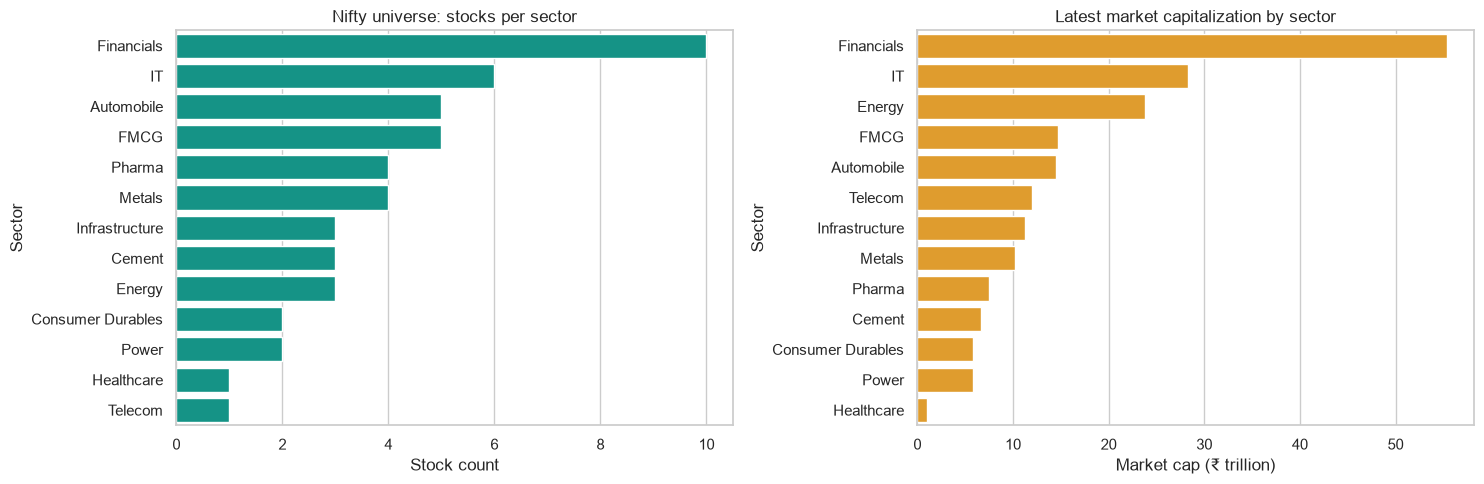

In [3]:
latest_fundamental_date = (
    select(
        StockFundamental.stock_id.label("stock_id"),
        func.max(StockFundamental.as_of_date).label("as_of_date"),
    )
    .group_by(StockFundamental.stock_id)
    .subquery()
)

async with SessionLocal() as session:
    sector_rows = (await session.execute(
        select(
            Sector.name,
            func.count(Stock.id),
            func.sum(StockFundamental.market_cap),
        )
        .join(Stock, Stock.sector_id == Sector.id)
        .join(latest_fundamental_date, latest_fundamental_date.c.stock_id == Stock.id)
        .join(
            StockFundamental,
            and_(
                StockFundamental.stock_id == latest_fundamental_date.c.stock_id,
                StockFundamental.as_of_date == latest_fundamental_date.c.as_of_date,
            ),
        )
        .group_by(Sector.name)
        .order_by(Sector.name)
    )).all()

sector_df = pd.DataFrame(sector_rows, columns=["sector", "stock_count", "market_cap_inr"])
sector_df["market_cap_trillion_inr"] = sector_df["market_cap_inr"].astype(float) / 1e12
display(sector_df[["sector", "stock_count", "market_cap_trillion_inr"]])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=sector_df.sort_values("stock_count", ascending=False), x="stock_count", y="sector", color=OPTIVEST["teal"], ax=axes[0])
axes[0].set(title="Nifty universe: stocks per sector", xlabel="Stock count", ylabel="Sector")
sns.barplot(data=sector_df.sort_values("market_cap_trillion_inr", ascending=False), x="market_cap_trillion_inr", y="sector", color=OPTIVEST["gold"], ax=axes[1])
axes[1].set(title="Latest market capitalization by sector", xlabel="Market cap (₹ trillion)", ylabel="Sector")
fig.tight_layout()
plt.show()

## Representative price histories

Prices are normalized to 100 at each series' first plotted observation. This compares growth paths without confusing the result with different rupee price levels.

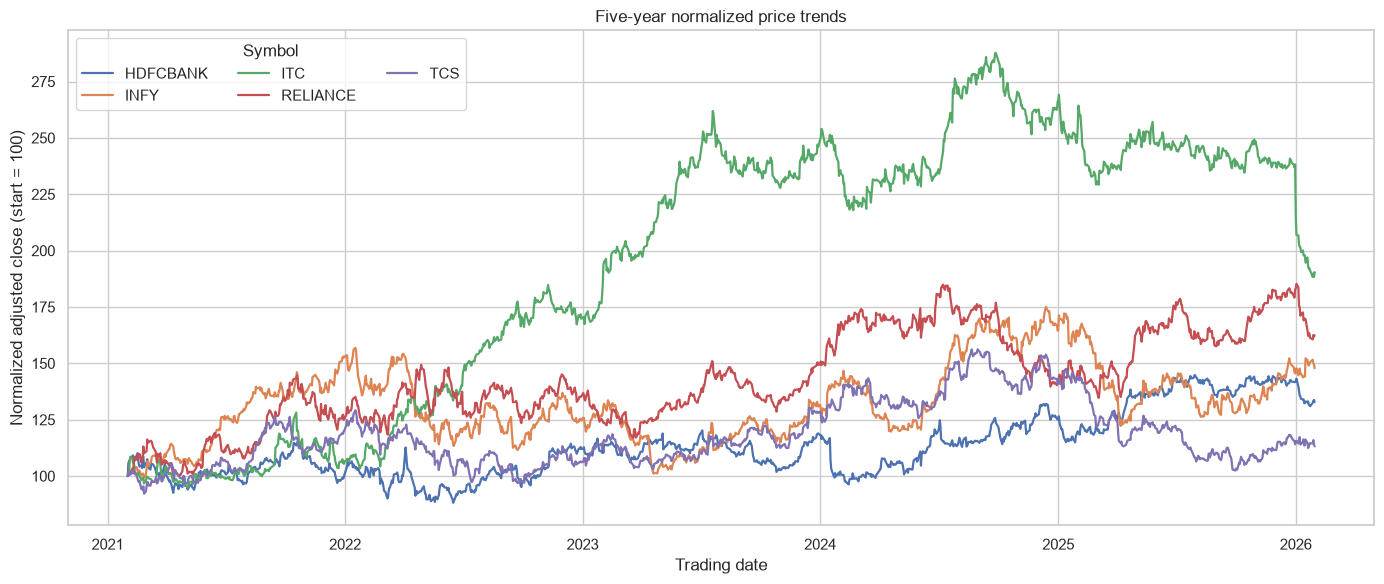

In [4]:
representatives = ("RELIANCE", "TCS", "HDFCBANK", "INFY", "ITC")
chart_start = max(coverage_df["last_date"]) - pd.Timedelta(days=5 * 365)
async with SessionLocal() as session:
    price_rows = (await session.execute(
        select(StockPrice.trade_date, Stock.symbol, StockPrice.adj_close)
        .join(Stock, Stock.id == StockPrice.stock_id)
        .where(Stock.symbol.in_(representatives), StockPrice.trade_date >= chart_start)
        .order_by(StockPrice.trade_date, Stock.symbol)
    )).all()

prices_df = pd.DataFrame(price_rows, columns=["date", "symbol", "adj_close_inr"])
prices_df["adj_close_inr"] = prices_df["adj_close_inr"].astype(float)
prices_df["normalized_price"] = prices_df.groupby("symbol")["adj_close_inr"].transform(lambda values: values / values.iloc[0] * 100)

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=prices_df, x="date", y="normalized_price", hue="symbol", linewidth=1.6, ax=ax)
ax.set(title="Five-year normalized price trends", xlabel="Trading date", ylabel="Normalized adjusted close (start = 100)")
ax.legend(title="Symbol", ncol=3)
fig.tight_layout()
plt.show()

## Return distribution and dependence

The universe-wide histogram uses all non-null stored daily returns. The heatmap uses dates shared by all 49 stocks, preventing missing listings from being silently treated as zero correlation.

,value
count,287214.000000
mean,0.001963
std,0.216064
skew,445.491273
kurtosis,221551.592168


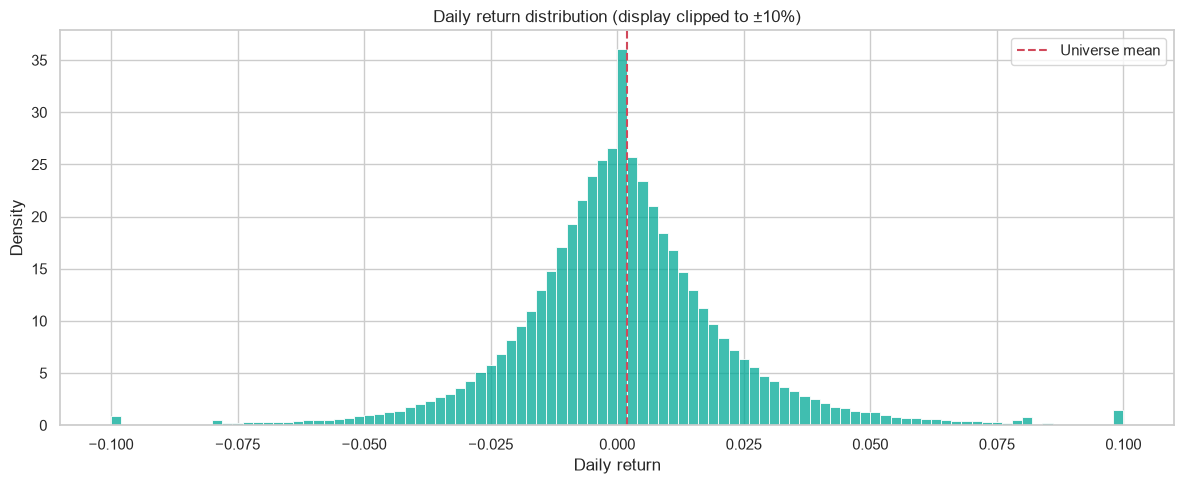

Aligned correlation sample: 2,026 dates × 49 stocks


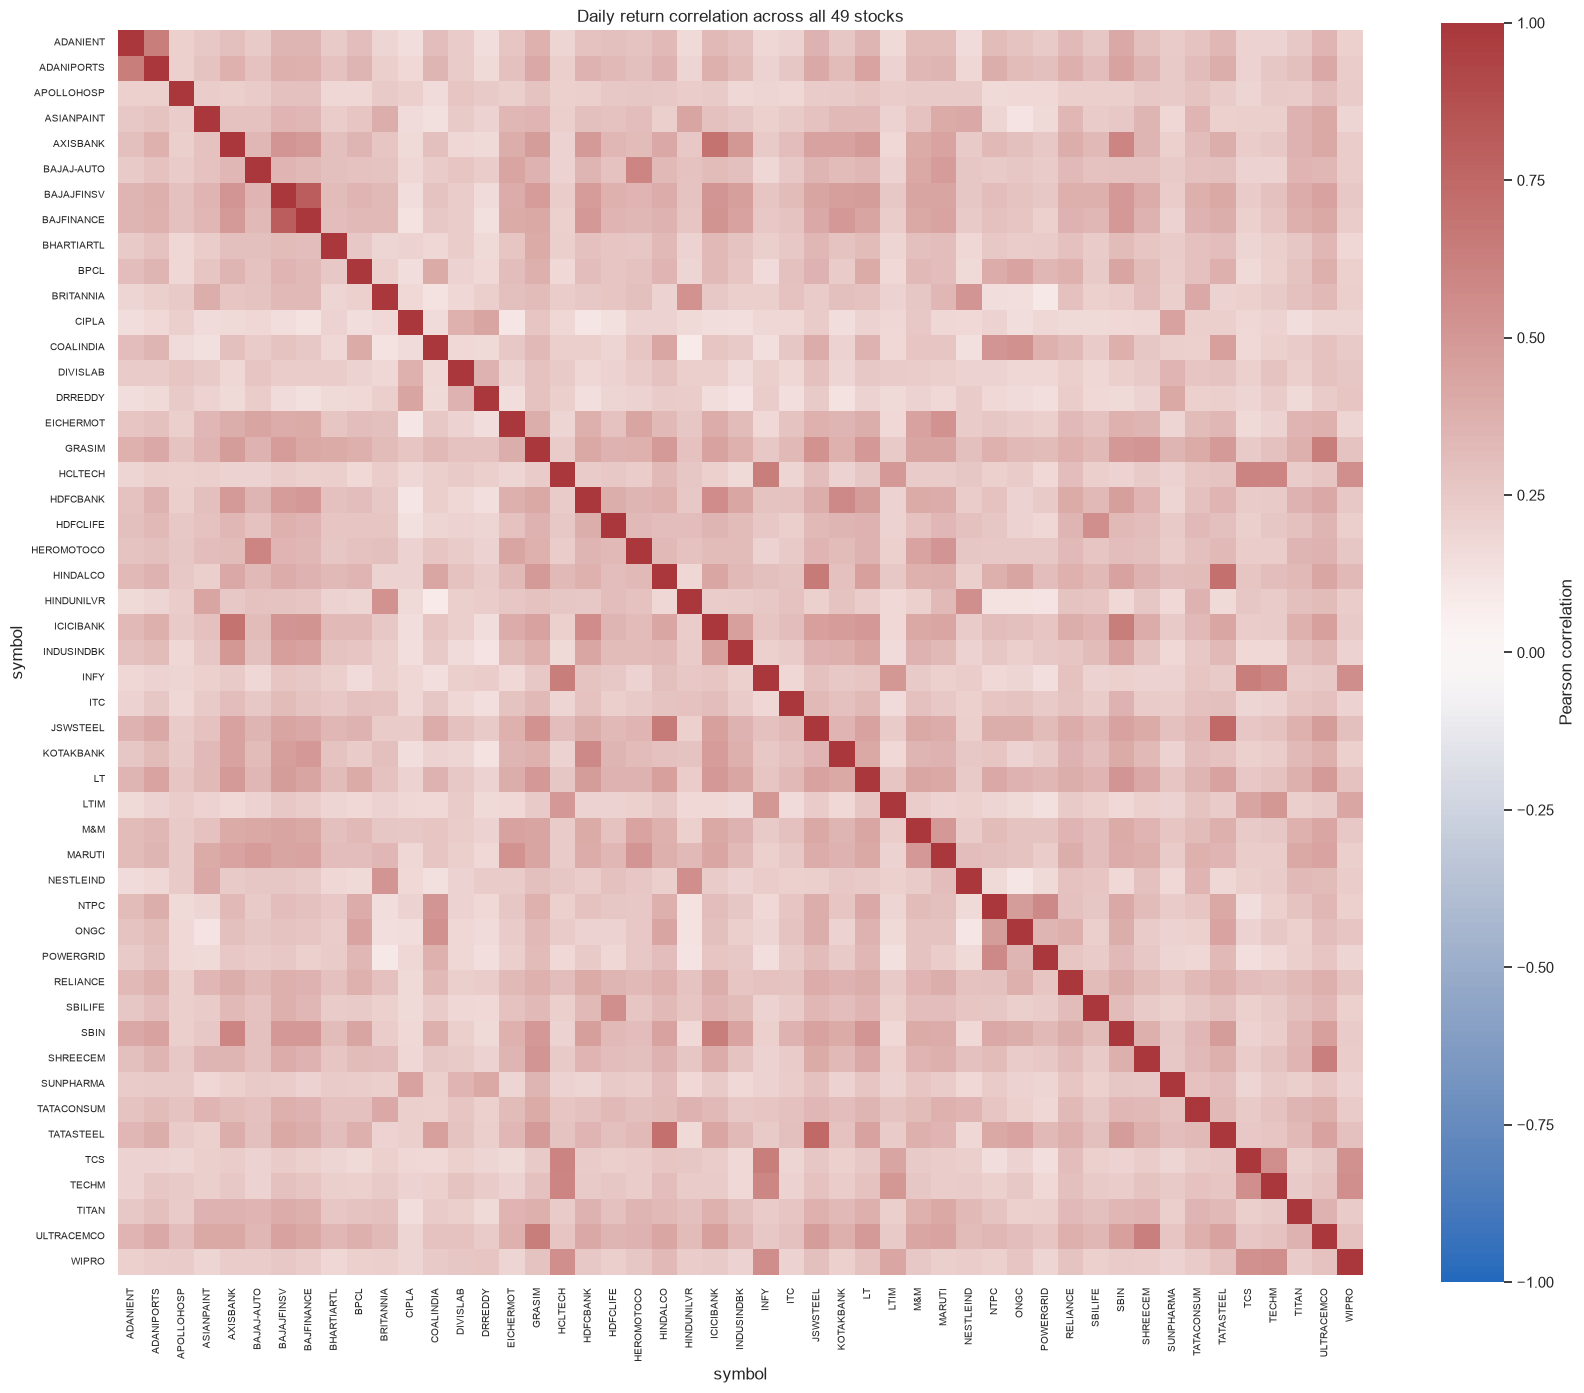

In [5]:
async with SessionLocal() as session:
    return_rows = (await session.execute(
        select(StockPrice.trade_date, Stock.symbol, StockPrice.daily_return)
        .join(Stock, Stock.id == StockPrice.stock_id)
        .where(StockPrice.daily_return.is_not(None))
        .order_by(StockPrice.trade_date, Stock.symbol)
    )).all()

returns_df = pd.DataFrame(return_rows, columns=["date", "symbol", "daily_return"])
returns_df["daily_return"] = returns_df["daily_return"].astype(float)
stats = returns_df["daily_return"].agg(["count", "mean", "std", "skew", "kurt"]).rename({"kurt": "kurtosis"})
display(stats.to_frame("value").style.format({"value": "{:.6f}"}))

fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(returns_df["daily_return"].clip(-0.10, 0.10), bins=100, color=OPTIVEST["teal"], stat="density", ax=ax)
ax.axvline(returns_df["daily_return"].mean(), color=OPTIVEST["red"], linestyle="--", label="Universe mean")
ax.set(title="Daily return distribution (display clipped to ±10%)", xlabel="Daily return", ylabel="Density")
ax.legend()
fig.tight_layout()
plt.show()

return_panel = returns_df.pivot(index="date", columns="symbol", values="daily_return").dropna()
correlation = return_panel.corr()
print(f"Aligned correlation sample: {len(return_panel):,} dates × {correlation.shape[0]} stocks")
fig, ax = plt.subplots(figsize=(17, 14))
sns.heatmap(correlation, cmap="vlag", center=0, vmin=-1, vmax=1, square=True, xticklabels=True, yticklabels=True, cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Daily return correlation across all 49 stocks")
ax.tick_params(axis="x", labelrotation=90, labelsize=7)
ax.tick_params(axis="y", labelsize=7)
fig.tight_layout()
plt.show()

## Annualized volatility and fundamentals

Volatility is estimated per stock from its complete stored daily-return history using the backend convention of 252 trading days. Fundamentals use one latest record per stock.

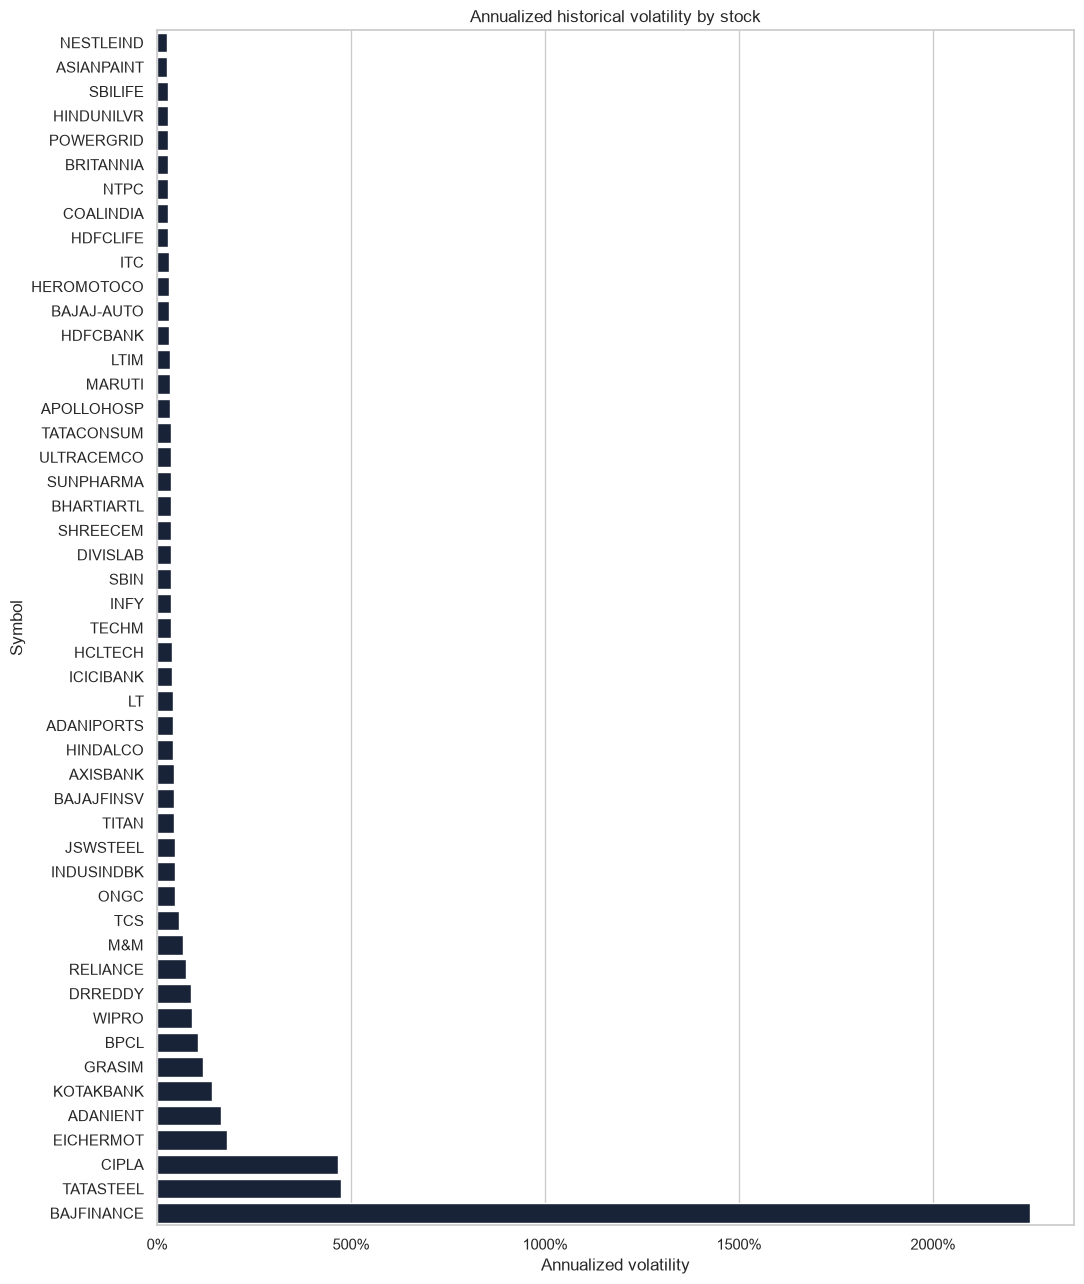

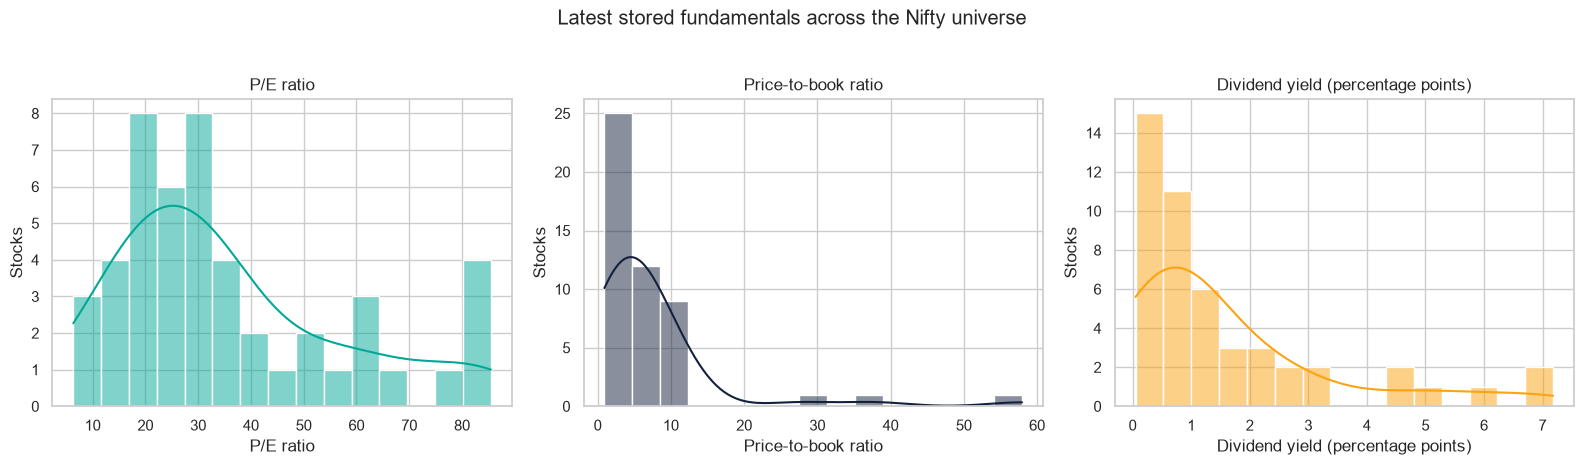

,count,mean,std,min,25%,50%,75%,max
pe_ratio,48.0000,35.5446,21.3355,6.3292,20.5102,30.7219,45.3585,85.4620
pb_ratio,49.0000,7.2982,9.7592,0.9192,2.5338,4.6251,7.8425,57.9405
dividend_yield_pct_points,48.0000,1.6210,1.8006,0.0500,0.4850,0.9500,2.0625,7.1800


In [6]:
from app.optimization.data import TRADING_DAYS

volatility_df = (
    returns_df.groupby("symbol")["daily_return"].std(ddof=1)
    .mul(np.sqrt(TRADING_DAYS))
    .sort_values()
    .rename("annualized_volatility")
    .reset_index()
)
fig, ax = plt.subplots(figsize=(11, 13))
sns.barplot(data=volatility_df, x="annualized_volatility", y="symbol", color=OPTIVEST["navy"], ax=ax)
ax.set(title="Annualized historical volatility by stock", xlabel="Annualized volatility", ylabel="Symbol")
ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
fig.tight_layout()
plt.show()

async with SessionLocal() as session:
    fundamental_rows = (await session.execute(
        select(
            Stock.symbol,
            StockFundamental.pe_ratio,
            StockFundamental.pb_ratio,
            StockFundamental.dividend_yield,
        )
        .join(latest_fundamental_date, latest_fundamental_date.c.stock_id == Stock.id)
        .join(
            StockFundamental,
            and_(
                StockFundamental.stock_id == latest_fundamental_date.c.stock_id,
                StockFundamental.as_of_date == latest_fundamental_date.c.as_of_date,
            ),
        )
        .order_by(Stock.symbol)
    )).all()

fundamentals_df = pd.DataFrame(fundamental_rows, columns=["symbol", "pe_ratio", "pb_ratio", "dividend_yield_pct_points"])
for column in fundamentals_df.columns[1:]:
    fundamentals_df[column] = pd.to_numeric(fundamentals_df[column], errors="coerce")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, column, title, color in zip(
    axes,
    ["pe_ratio", "pb_ratio", "dividend_yield_pct_points"],
    ["P/E ratio", "Price-to-book ratio", "Dividend yield (percentage points)"],
    [OPTIVEST["teal"], OPTIVEST["navy"], OPTIVEST["gold"]],
    strict=True,
):
    sns.histplot(fundamentals_df[column].dropna(), bins=15, kde=True, color=color, ax=ax)
    ax.set(title=title, xlabel=title, ylabel="Stocks")
fig.suptitle("Latest stored fundamentals across the Nifty universe", y=1.03)
fig.tight_layout()
plt.show()
display(fundamentals_df.describe().T)

## Data-quality checkpoint

The following note is extracted from the audited `data/PROFILE_REPORT.md`, keeping the presentation notebook tied to the project's recorded ETL evidence.

In [7]:
import re

profile_text = (REPO_ROOT / "data" / "PROFILE_REPORT.md").read_text(encoding="utf-8")
accepted = re.search(r"real load produced (\d+) stocks and ([\d,]+) rows", profile_text)
rejected = re.search(r"Forty-seven rows have zero for every OHLC value and were rejected", profile_text)
symbol_count = int(accepted.group(1)) if accepted else len(coverage_df)
loaded_rows = accepted.group(2) if accepted else f"{row_counts['stock_prices']:,}"
display(Markdown(
    f"- **49 rather than 50 stocks:** the source export contains {symbol_count} unique tickers; the notebook does not invent a missing constituent.\n"
    f"- **Zero-OHLC rejection:** {'47 invalid rows were rejected during ETL' if rejected else 'see PROFILE_REPORT.md for rejected-row details'}.\n"
    f"- **Loaded dated rows:** {loaded_rows} valid observations are present in each dated destination table.\n"
    f"- **Source of record:** [`data/PROFILE_REPORT.md`](../data/PROFILE_REPORT.md)."
))

- **49 rather than 50 stocks:** the source export contains 49 unique tickers; the notebook does not invent a missing constituent.
- **Zero-OHLC rejection:** 47 invalid rows were rejected during ETL.
- **Loaded dated rows:** 287,263 valid observations are present in each dated destination table.
- **Source of record:** [`data/PROFILE_REPORT.md`](../data/PROFILE_REPORT.md).

In [8]:
await ENGINE.dispose()
print("Database engine disposed; no writes were issued.")

Database engine disposed; no writes were issued.


## Key takeaway

OptiVest is backed by a long, internally reconciled 49-stock history rather than a small demonstration fixture. Coverage differs by listing date, returns are heavy-tailed and correlated, sector size is uneven, and fundamentals contain expected nulls—conditions the optimization and validation methodology must explicitly respect.